In [1]:
import sys
sys.path.append("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo")

from datasets.llff_dataset import LLFFDataset

In [2]:
import yaml

with open("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/ckpts/fern/fern_ndc_20240914-153425/config.yaml") as f:
    cfg = yaml.load(f, Loader=yaml.FullLoader)
    cfg['device'] = 'cuda:3'
    cfg['ndc'] = True
    
cfg['dataset']['base_dir'] = '/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/data/nerf_llff_data/fern'
dset = LLFFDataset(cfg['dataset'])

/home/diya/anaconda3/envs/tensorRT_JY/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [3]:
sp = dset.spiral_poses
pp = dset.poses

In [4]:
dset.get_H(), dset.get_W(), dset.get_focal(), dset.get_K()[0][0], dset.fars.max(), dset.nears.min()

(378, 504, 407.5657958984375, 407.5657958984375, tensor(1.), tensor(0.))

In [5]:
import sys
sys.path.append("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo")

from nerf.models import nerf
from nerf.models import build_model
from nerf.engines import build_engine
import torch


In [6]:
# state_dict = torch.load("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/ckpts/trex/20240912-145426/ckpt_1000.pt", map_location='cuda:1')
state_dict = torch.load("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/ckpts/fern/fern_ndc_20240914-153425/ckpt_2000.pt", map_location='cuda:3')

In [7]:
# model = nerf.NeRF()

model = build_engine(cfg)

Expected last learning rate: 5.15377520732012e-06


In [8]:
model.load_state_dict(state_dict)

Loaded state dict from epoch 2000


In [14]:
out = model.render_spiral(dset, batch_size=8192, test=1, render_train=False)

4 images will be rendered.


Rendering...: 100%|███████████████████████████████████████████████████| 4/4 [01:40<00:00, 25.20s/it]


(-0.5, 503.5, 377.5, -0.5)

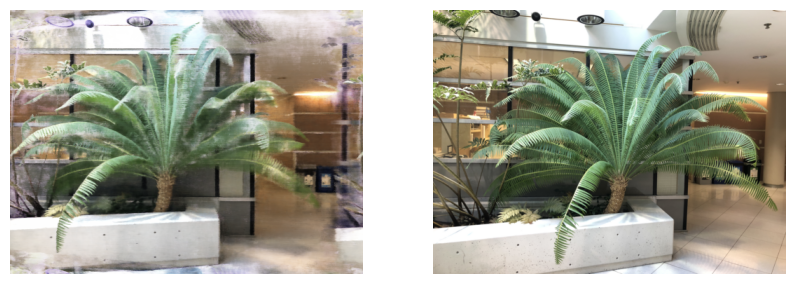

In [27]:
import matplotlib.pyplot as plt

H, W = dset.get_H(), dset.get_W()

idx = 0

sample = out[idx].view(-1, H, W, 3)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(sample[0])
plt.axis("off")
plt.subplot(122)
plt.imshow(dset.images[idx].permute(1, 2, 0))
plt.axis("off")

In [24]:
import numpy as np

np.arange(20)[::8]

array([ 0,  8, 16])

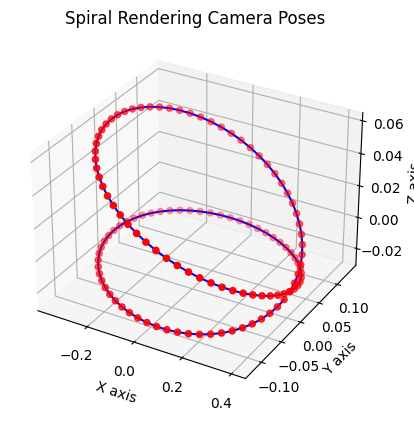

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_spiral_poses(poses):
    """
    Visualize the camera positions in 3D space for spiral rendering.
    Args:
        poses: np.array of shape (n_views, 3, 5) containing the camera extrinsics.
    """
    # Extract the camera positions (translation part)
    camera_positions = poses[:, :3, 3]  # Assuming translation is stored in the last column
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the camera positions
    ax.scatter(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2], c='r', marker='o')
    
    # Optionally, you can draw lines between consecutive camera positions to visualize the spiral
    ax.plot(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2], color='blue')
    
    # Label axes
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    
    plt.title('Spiral Rendering Camera Poses')
    plt.show()

# Example usage
# Assuming poses is a numpy array of shape (n_views, 3, 5)
# Replace this with your actual poses data
visualize_spiral_poses(np.array(sp[:, :3, :4]))


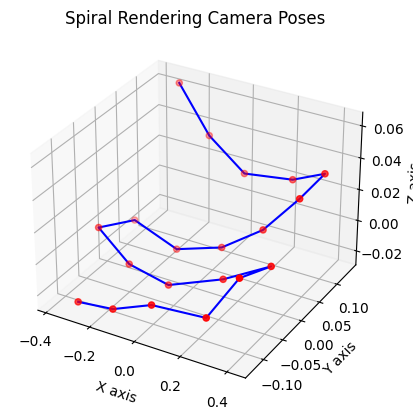

In [11]:
visualize_spiral_poses(np.array(dset.poses))

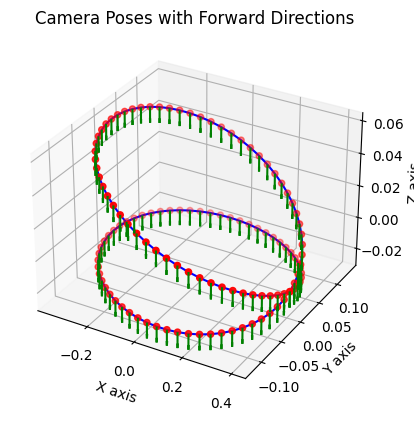

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_camera_poses_with_directions(poses):
    """
    Visualize the camera positions and forward directions in 3D space for spiral rendering.
    
    Args:
        poses: np.array of shape (n_views, 3, 5) containing the camera extrinsics.
    """
    # Extract the camera positions (translation part)
    camera_positions = poses[:, :3, 3]  # Assuming translation is stored in the last column
    
    # Extract the forward directions (3rd column of the 3x3 rotation matrix)
    forward_directions = poses[:, :3, 2]  # Assuming the 3rd column of the 3x3 matrix is the forward direction

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the camera positions
    ax.scatter(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2], c='r', marker='o')
    
    # Plot lines between consecutive camera positions to show the spiral path
    ax.plot(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2], color='blue')
    
    # Plot camera forward directions as quivers (arrows)
    ax.quiver(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2],
              forward_directions[:, 0], forward_directions[:, 1], forward_directions[:, 2],
              length=0.01, normalize=True, color='green')

    # Label axes
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    
    plt.title('Camera Poses with Forward Directions')
    plt.show()

# Example usage
# Replace this with your actual pose data, shaped (n_views, 3, 5)

visualize_camera_poses_with_directions(np.array(sp))


In [13]:
from nerf.ray import ndc_rays
ndc_ray = ndc_rays(dset.get_H(), dset.get_W(), dset.focal, 1, dset.ray_origins, dset.ray_directions)
# visualize_camera_poses_with_directions(np.array(dset.poses))

In [6]:
dset.ray_origins.shape

torch.Size([20, 190512, 3])

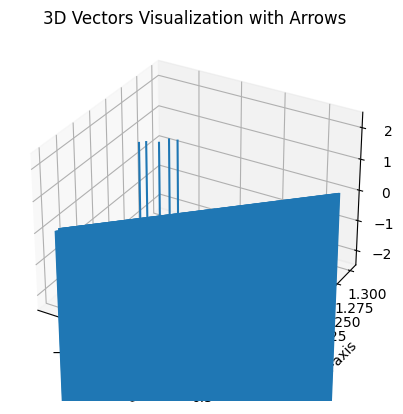

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generating random Nx3 origins and direction vectors for demonstration
N = 50
origins = ndc_ray[0][0][:1000]
directions = ndc_ray[1][0][:1000]

# origins = dset.ray_origins[0][:1000]
# directions = dset.ray_directions[0][:1000]

# Plotting the Nx3 origins and direction vectors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Extracting x, y, z coordinates for origins and directions
x, y, z = origins[:, 0], origins[:, 1], origins[:, 2]
u, v, w = directions[:, 0], directions[:, 1], directions[:, 2]

# Plot arrows representing vectors
ax.quiver(x, y, z, u, v, w, length=0.01, normalize=True)

# Setting labels
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('3D Vectors Visualization with Arrows')

# Show plot
plt.show()


In [14]:
images = [o.view(-1, H, W, 3)[0] for o in out]

In [17]:
from src.metrics import calculate_psnr

# calculate_psnr(images[0], dset.images[0])

In [18]:
# calculate_psnr(images[1], dset.images[1].permute(1, 2, 0)),

from torch.nn.functional import mse_loss
idx = 0
mse_loss(images[idx], dset.images[idx].permute(1, 2, 0))
# images[0].shape, dset.images[0].permute(1, 2, 0).shape

tensor(0.0020)

In [21]:
import math

math.log10(0.0017)

-2.769551078621726

In [7]:
d = dset.ray_directions
p = dset.poses

In [8]:
import numpy as np
import os, imageio


########## Slightly modified version of LLFF data loading code 
##########  see https://github.com/Fyusion/LLFF for original

def _minify(basedir, factors=[], resolutions=[]):
    needtoload = False
    for r in factors:
        imgdir = os.path.join(basedir, 'images_{}'.format(r))
        if not os.path.exists(imgdir):
            needtoload = True
    for r in resolutions:
        imgdir = os.path.join(basedir, 'images_{}x{}'.format(r[1], r[0]))
        if not os.path.exists(imgdir):
            needtoload = True
    if not needtoload:
        return
    
    from shutil import copy
    from subprocess import check_output
    
    imgdir = os.path.join(basedir, 'images')
    imgs = [os.path.join(imgdir, f) for f in sorted(os.listdir(imgdir))]
    imgs = [f for f in imgs if any([f.endswith(ex) for ex in ['JPG', 'jpg', 'png', 'jpeg', 'PNG']])]
    imgdir_orig = imgdir
    
    wd = os.getcwd()

    for r in factors + resolutions:
        if isinstance(r, int):
            name = 'images_{}'.format(r)
            resizearg = '{}%'.format(100./r)
        else:
            name = 'images_{}x{}'.format(r[1], r[0])
            resizearg = '{}x{}'.format(r[1], r[0])
        imgdir = os.path.join(basedir, name)
        if os.path.exists(imgdir):
            continue
            
        print('Minifying', r, basedir)
        
        os.makedirs(imgdir)
        check_output('cp {}/* {}'.format(imgdir_orig, imgdir), shell=True)
        
        ext = imgs[0].split('.')[-1]
        args = ' '.join(['mogrify', '-resize', resizearg, '-format', 'png', '*.{}'.format(ext)])
        print(args)
        os.chdir(imgdir)
        check_output(args, shell=True)
        os.chdir(wd)
        
        if ext != 'png':
            check_output('rm {}/*.{}'.format(imgdir, ext), shell=True)
            print('Removed duplicates')
        print('Done')
            
        
        
        
def _load_data(basedir, factor=None, width=None, height=None, load_imgs=True):
    
    poses_arr = np.load(os.path.join(basedir, 'poses_bounds.npy'))
    poses = poses_arr[:, :-2].reshape([-1, 3, 5]).transpose([1,2,0])
    bds = poses_arr[:, -2:].transpose([1,0])
    
    img0 = [os.path.join(basedir, 'images', f) for f in sorted(os.listdir(os.path.join(basedir, 'images'))) \
            if f.endswith('JPG') or f.endswith('jpg') or f.endswith('png')][0]
    sh = imageio.imread(img0).shape
    
    sfx = ''
    
    if factor is not None:
        sfx = '_{}'.format(factor)
        _minify(basedir, factors=[factor])
        factor = factor
    elif height is not None:
        factor = sh[0] / float(height)
        width = int(sh[1] / factor)
        _minify(basedir, resolutions=[[height, width]])
        sfx = '_{}x{}'.format(width, height)
    elif width is not None:
        factor = sh[1] / float(width)
        height = int(sh[0] / factor)
        _minify(basedir, resolutions=[[height, width]])
        sfx = '_{}x{}'.format(width, height)
    else:
        factor = 1
    
    imgdir = os.path.join(basedir, 'images' + sfx)
    if not os.path.exists(imgdir):
        print( imgdir, 'does not exist, returning' )
        return
    
    imgfiles = [os.path.join(imgdir, f) for f in sorted(os.listdir(imgdir)) if f.endswith('JPG') or f.endswith('jpg') or f.endswith('png')]
    if poses.shape[-1] != len(imgfiles):
        print( 'Mismatch between imgs {} and poses {} !!!!'.format(len(imgfiles), poses.shape[-1]) )
        return
    
    sh = imageio.imread(imgfiles[0]).shape
    poses[:2, 4, :] = np.array(sh[:2]).reshape([2, 1])
    poses[2, 4, :] = poses[2, 4, :] * 1./factor
    
    if not load_imgs:
        return poses, bds
    
    def imread(f):
        if f.endswith('png'):
            return imageio.imread(f)
        else:
            return imageio.imread(f)
        
    imgs = imgs = [imread(f)[...,:3]/255. for f in imgfiles]
    imgs = np.stack(imgs, -1)  
    
    print('Loaded image data', imgs.shape, poses[:,-1,0])
    return poses, bds, imgs

    
            
            
    

def normalize(x):
    return x / np.linalg.norm(x)

def viewmatrix(z, up, pos):
    vec2 = normalize(z)
    vec1_avg = up
    vec0 = normalize(np.cross(vec1_avg, vec2))
    vec1 = normalize(np.cross(vec2, vec0))
    m = np.stack([vec0, vec1, vec2, pos], 1)
    return m

def ptstocam(pts, c2w):
    tt = np.matmul(c2w[:3,:3].T, (pts-c2w[:3,3])[...,np.newaxis])[...,0]
    return tt

def poses_avg(poses):

    hwf = poses[0, :3, -1:]

    center = poses[:, :3, 3].mean(0)
    vec2 = normalize(poses[:, :3, 2].sum(0))
    up = poses[:, :3, 1].sum(0)
    c2w = np.concatenate([viewmatrix(vec2, up, center), hwf], 1)
    
    return c2w



def render_path_spiral(c2w, up, rads, focal, zdelta, zrate, rots, N):
    render_poses = []
    rads = np.array(list(rads) + [1.])
    hwf = c2w[:,4:5]
    
    for theta in np.linspace(0., 2. * np.pi * rots, N+1)[:-1]:
        c = np.dot(c2w[:3,:4], np.array([np.cos(theta), -np.sin(theta), -np.sin(theta*zrate), 1.]) * rads) 
        z = normalize(c - np.dot(c2w[:3,:4], np.array([0,0,-focal, 1.])))
        render_poses.append(np.concatenate([viewmatrix(z, up, c), hwf], 1))
    return render_poses
    


def recenter_poses(poses):

    poses_ = poses+0
    bottom = np.reshape([0,0,0,1.], [1,4])
    c2w = poses_avg(poses)
    c2w = np.concatenate([c2w[:3,:4], bottom], -2)
    bottom = np.tile(np.reshape(bottom, [1,1,4]), [poses.shape[0],1,1])
    poses = np.concatenate([poses[:,:3,:4], bottom], -2)

    poses = np.linalg.inv(c2w) @ poses
    poses_[:,:3,:4] = poses[:,:3,:4]
    poses = poses_
    return poses


#####################


def spherify_poses(poses, bds):
    
    p34_to_44 = lambda p : np.concatenate([p, np.tile(np.reshape(np.eye(4)[-1,:], [1,1,4]), [p.shape[0], 1,1])], 1)
    
    rays_d = poses[:,:3,2:3]
    rays_o = poses[:,:3,3:4]

    def min_line_dist(rays_o, rays_d):
        A_i = np.eye(3) - rays_d * np.transpose(rays_d, [0,2,1])
        b_i = -A_i @ rays_o
        pt_mindist = np.squeeze(-np.linalg.inv((np.transpose(A_i, [0,2,1]) @ A_i).mean(0)) @ (b_i).mean(0))
        return pt_mindist

    pt_mindist = min_line_dist(rays_o, rays_d)
    
    center = pt_mindist
    up = (poses[:,:3,3] - center).mean(0)

    vec0 = normalize(up)
    vec1 = normalize(np.cross([.1,.2,.3], vec0))
    vec2 = normalize(np.cross(vec0, vec1))
    pos = center
    c2w = np.stack([vec1, vec2, vec0, pos], 1)

    poses_reset = np.linalg.inv(p34_to_44(c2w[None])) @ p34_to_44(poses[:,:3,:4])

    rad = np.sqrt(np.mean(np.sum(np.square(poses_reset[:,:3,3]), -1)))
    
    sc = 1./rad
    poses_reset[:,:3,3] *= sc
    bds *= sc
    rad *= sc
    
    centroid = np.mean(poses_reset[:,:3,3], 0)
    zh = centroid[2]
    radcircle = np.sqrt(rad**2-zh**2)
    new_poses = []
    
    for th in np.linspace(0.,2.*np.pi, 120):

        camorigin = np.array([radcircle * np.cos(th), radcircle * np.sin(th), zh])
        up = np.array([0,0,-1.])

        vec2 = normalize(camorigin)
        vec0 = normalize(np.cross(vec2, up))
        vec1 = normalize(np.cross(vec2, vec0))
        pos = camorigin
        p = np.stack([vec0, vec1, vec2, pos], 1)

        new_poses.append(p)

    new_poses = np.stack(new_poses, 0)
    
    new_poses = np.concatenate([new_poses, np.broadcast_to(poses[0,:3,-1:], new_poses[:,:3,-1:].shape)], -1)
    poses_reset = np.concatenate([poses_reset[:,:3,:4], np.broadcast_to(poses[0,:3,-1:], poses_reset[:,:3,-1:].shape)], -1)
    
    return poses_reset, new_poses, bds
    

def load_llff_data(basedir, factor=8, recenter=True, bd_factor=.75, spherify=False, path_zflat=False):
    

    poses, bds, imgs = _load_data(basedir, factor=factor) # factor=8 downsamples original imgs by 8x
    print('Loaded', basedir, bds.min(), bds.max())
    
    # Correct rotation matrix ordering and move variable dim to axis 0
    poses = np.concatenate([poses[:, 1:2, :], -poses[:, 0:1, :], poses[:, 2:, :]], 1)
    poses = np.moveaxis(poses, -1, 0).astype(np.float32)
    imgs = np.moveaxis(imgs, -1, 0).astype(np.float32)
    images = imgs
    bds = np.moveaxis(bds, -1, 0).astype(np.float32)
    
    # Rescale if bd_factor is provided
    sc = 1. if bd_factor is None else 1./(bds.min() * bd_factor)
    poses[:,:3,3] *= sc
    bds *= sc
    
    if recenter:
        poses = recenter_poses(poses)
        
    if spherify:
        poses, render_poses, bds = spherify_poses(poses, bds)

    else:
        
        c2w = poses_avg(poses)
        print('recentered', c2w.shape)
        print(c2w[:3,:4])

        ## Get spiral
        # Get average pose
        up = normalize(poses[:, :3, 1].sum(0))

        # Find a reasonable "focus depth" for this dataset
        close_depth, inf_depth = bds.min()*.9, bds.max()*5.
        dt = .75
        mean_dz = 1./(((1.-dt)/close_depth + dt/inf_depth))
        focal = mean_dz

        # Get radii for spiral path
        shrink_factor = .8
        zdelta = close_depth * .2
        tt = poses[:,:3,3] # ptstocam(poses[:3,3,:].T, c2w).T
        rads = np.percentile(np.abs(tt), 90, 0)
        c2w_path = c2w
        N_views = 120
        N_rots = 2
        if path_zflat:
#             zloc = np.percentile(tt, 10, 0)[2]
            zloc = -close_depth * .1
            c2w_path[:3,3] = c2w_path[:3,3] + zloc * c2w_path[:3,2]
            rads[2] = 0.
            N_rots = 1
            N_views/=2

        # Generate poses for spiral path
        render_poses = render_path_spiral(c2w_path, up, rads, focal, zdelta, zrate=.5, rots=N_rots, N=N_views)
        
        
    render_poses = np.array(render_poses).astype(np.float32)

    c2w = poses_avg(poses)
    print('Data:')
    print(poses.shape, images.shape, bds.shape)
    
    dists = np.sum(np.square(c2w[:3,3] - poses[:,:3,3]), -1)
    i_test = np.argmin(dists)
    print('HOLDOUT view is', i_test)
    
    images = images.astype(np.float32)
    poses = poses.astype(np.float32)

    return images, poses, bds, render_poses, i_test





In [9]:
img, pose, bds, rp, it = load_llff_data("/home/diya/Public/Image2Smiles/jy/NeRF-Zoo/data/nerf_llff_data/fern",
               factor=8, recenter=True, bd_factor=.75, spherify=False, path_zflat=False)

/tmp/ipykernel_109687/3694808943.py:70: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  sh = imageio.imread(img0).shape
/tmp/ipykernel_109687/3694808943.py:101: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  sh = imageio.imread(imgfiles[0]).shape
/tmp/ipykernel_109687/3694808943.py:110: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  return imageio.imread(f)


Loaded image data (378, 504, 3, 20) [378.         504.         407.56579161]
Loaded /home/diya/Public/Image2Smiles/jy/NeRF-Zoo/data/nerf_llff_data/fern 16.985296178676084 80.00209740336334
recentered (3, 5)
[[ 1.0000000e+00  0.0000000e+00  0.0000000e+00  1.4901161e-09]
 [ 0.0000000e+00  1.0000000e+00 -1.8730975e-09 -9.6857544e-09]
 [-0.0000000e+00  1.8730975e-09  1.0000000e+00  0.0000000e+00]]
Data:
(20, 3, 5) (20, 378, 504, 3) (20, 2)
HOLDOUT view is 12


In [11]:
pose.shape, p.shape

((20, 3, 5), torch.Size([20, 3, 4]))

In [12]:
pose[0][:, :4], p[0]

(array([[ 0.99569476, -0.02079598, -0.09033062, -0.3081002 ],
        [ 0.02503342,  0.9986262 ,  0.04603354,  0.1346772 ],
        [ 0.0892492 , -0.04809664,  0.99484736,  0.03989876]],
       dtype=float32),
 tensor([[ 0.9957, -0.0208, -0.0903, -0.3081],
         [ 0.0250,  0.9986,  0.0460,  0.1347],
         [ 0.0892, -0.0481,  0.9948,  0.0399]]))

In [15]:
def get_rays(H, W, K, c2w):
    i, j = torch.meshgrid(torch.linspace(0, W-1, W), torch.linspace(0, H-1, H))  # pytorch's meshgrid has indexing='ij'
    i = i.t()
    j = j.t()
    dirs = torch.stack([(i-K[0][2])/K[0][0], -(j-K[1][2])/K[1][1], -torch.ones_like(i)], -1)
    # Rotate ray directions from camera frame to the world frame
    rays_d = torch.sum(dirs[..., np.newaxis, :] * c2w[:3,:3], -1)  # dot product, equals to: [c2w.dot(dir) for dir in dirs]
    # Translate camera frame's origin to the world frame. It is the origin of all rays.
    rays_o = c2w[:3,-1].expand(rays_d.shape)
    return rays_o, rays_d

In [34]:
import torch
H, W, K = dset.get_H(), dset.get_W(), dset.get_K()

rayo, rayd = get_rays(H, W, K, torch.tensor(pose[0][:, :4]))
rayo2, rayd2 = dset.ray_origins[0].reshape(rayo.shape), dset.ray_directions[0].reshape(rayd.shape)

In [39]:
def ndc_rays(H, W, focal, near, rays_o, rays_d):
    # Shift ray origins to near plane
    t = -(near + rays_o[...,2]) / rays_d[...,2]
    rays_o = rays_o + t[...,None] * rays_d
    
    # Projection
    o0 = -1./(W/(2.*focal)) * rays_o[...,0] / rays_o[...,2]
    o1 = -1./(H/(2.*focal)) * rays_o[...,1] / rays_o[...,2]
    o2 = 1. + 2. * near / rays_o[...,2]
    
    d0 = -1./(W/(2.*focal)) * (rays_d[...,0]/rays_d[...,2] - rays_o[...,0]/rays_o[...,2])
    d1 = -1./(H/(2.*focal)) * (rays_d[...,1]/rays_d[...,2] - rays_o[...,1]/rays_o[...,2])
    d2 = -2. * near / rays_o[...,2]
    
    rays_o = torch.stack([o0,o1,o2], -1)
    rays_d = torch.stack([d0,d1,d2], -1)
    
    return rays_o, rays_d


ndc_rays(H, W, dset.get_focal(), 1, rayo, rayd)

(tensor([[[-1.3373,  1.1302, -1.0000],
          [-1.3337,  1.1305, -1.0000],
          [-1.3300,  1.1308, -1.0000],
          ...,
          [ 0.7055,  1.2976, -1.0000],
          [ 0.7100,  1.2980, -1.0000],
          [ 0.7146,  1.2983, -1.0000]],
 
         [[-1.3373,  1.1252, -1.0000],
          [-1.3337,  1.1255, -1.0000],
          [-1.3300,  1.1258, -1.0000],
          ...,
          [ 0.7057,  1.2920, -1.0000],
          [ 0.7103,  1.2924, -1.0000],
          [ 0.7148,  1.2928, -1.0000]],
 
         [[-1.3374,  1.1201, -1.0000],
          [-1.3337,  1.1204, -1.0000],
          [-1.3300,  1.1207, -1.0000],
          ...,
          [ 0.7060,  1.2864, -1.0000],
          [ 0.7105,  1.2868, -1.0000],
          [ 0.7151,  1.2872, -1.0000]],
 
         ...,
 
         [[-1.3421, -0.8378, -1.0000],
          [-1.3383, -0.8379, -1.0000],
          [-1.3345, -0.8380, -1.0000],
          ...,
          [ 0.7985, -0.8975, -1.0000],
          [ 0.8033, -0.8976, -1.0000],
          [ 0.8081

In [2]:
import torch


In [13]:
import time

s = time.time()
device = 'cpu'

a = torch.ones(3, 500, 500).to(device)
b = torch.ones(3, 500, 500).to(device)

In [14]:
for i in range(1000):
    a = torch.ones(3, 500, 500).to(device)
    b = torch.ones(3, 500, 500).to(device)

torch.nn.MSELoss()(a, b)

e = time.time()

print(s-e)

-0.2699296474456787
